In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import time

In [8]:
print("Fetching MNIST dataset")
mnist = fetch_openml('mnist_784', version=1, cache=True, parser='auto')

X = mnist.data.values.astype('float32') / 255.0
y = mnist.target.values.astype('int')

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=60000, test_size=10000, random_state=42)
print(f"{X_train.shape[0]} train samples, {X_test.shape[0]} test samples.\n")

Fetching MNIST dataset... (This may take a minute)
Data ready: 60000 train samples, 10000 test samples.



In [9]:
d = 2
T_exp = 2  
epochs = int(T_exp)

M_x_list = [] # Stores mistake features for each class
M_y_list = [] # Stores mistake labels for each class
C_vecs = []   # Stores survival times

print(f"Starting Kernel Training (d={d}, T={T_exp})")
start_train_time = time.time()

for c in range(10):
    c_start_time = time.time()
    y_bin = np.where(y_train == c, 1, -1)
    
    mistakes = []
    C = [0]
    
    for epoch in range(epochs):
        for i in range(len(X_train)):
            x_i = X_train[i]
            y_i = y_bin[i]
            
            if len(mistakes) == 0:
                v_dot_x = 0.0
            else:
                # Vectorized kernel calculation against all historical mistakes
                M_x_arr = np.array([m[0] for m in mistakes])
                M_y_arr = np.array([m[1] for m in mistakes])
                v_dot_x = np.sum(M_y_arr * ((np.dot(M_x_arr, x_i) + 1.0) ** d))
                
            y_hat = 1 if v_dot_x >= 0 else -1
            
            if y_hat == y_i:
                C[-1] += 1
            else:
                mistakes.append((x_i, y_i))
                C.append(1)
                
    # Save the history matrices for this class
    if len(mistakes) > 0:
        M_x_list.append(np.array([m[0] for m in mistakes]))
        M_y_list.append(np.array([m[1] for m in mistakes]))
    else:
        M_x_list.append(np.empty((0, X_train.shape[1])))
        M_y_list.append(np.empty(0))
        
    C_vecs.append(np.array(C))
    print(f"  Class {c} completed in {time.time() - c_start_time:.1f}s | Total mistakes: {len(mistakes)}")

print(f"Training Complete! Total time: {time.time() - start_train_time:.1f}s\n")

Starting Kernel Training (d=2, T=2)
  Class 0 completed in 95.2s | Total mistakes: 813
  Class 1 completed in 79.5s | Total mistakes: 684
  Class 2 completed in 161.1s | Total mistakes: 1489
  Class 3 completed in 204.2s | Total mistakes: 1924
  Class 4 completed in 153.3s | Total mistakes: 1378
  Class 5 completed in 173.8s | Total mistakes: 1606
  Class 6 completed in 110.9s | Total mistakes: 978
  Class 7 completed in 147.5s | Total mistakes: 1378
  Class 8 completed in 243.9s | Total mistakes: 2329
  Class 9 completed in 260.0s | Total mistakes: 2444
Training Complete! Total time: 1629.3s



In [10]:
print("Evaluating")
start_eval_time = time.time()

batch_size = 1000
y_pred_all = np.zeros(len(X_test))
conf_method_1 = np.zeros(len(X_test))
conf_method_2 = np.zeros(len(X_test))

for i in range(0, len(X_test), batch_size):
    X_batch = X_test[i:i+batch_size]
    
    batch_scores = np.zeros((len(X_batch), 10))
    batch_signs_list = []
    
    for c in range(10):
        if len(M_x_list[c]) > 0:
            # Compute the polynomial kernel matrix for the batch against history
            K_matrix = (np.dot(X_batch, M_x_list[c].T) + 1.0) ** d
            K_weighted = K_matrix * M_y_list[c]
            
            # Cumulative sum to track the intermediate vote states
            H_vals = np.hstack([np.zeros((len(X_batch), 1)), np.cumsum(K_weighted, axis=1)])
            signs = np.where(H_vals >= 0, 1, -1)
            
            batch_signs_list.append(signs)
            batch_scores[:, c] = np.dot(signs, C_vecs[c])
        else:
            # Fallback if a class somehow made 0 mistakes
            batch_signs_list.append(np.ones((len(X_batch), 1)))
            batch_scores[:, c] = np.ones(len(X_batch)) * C_vecs[c][0]
            
    # Find winning class
    y_pred_batch = np.argmax(batch_scores, axis=1)
    y_pred_all[i:i+batch_size] = y_pred_batch
    
    # Calculate Confidences
    for j in range(len(X_batch)):
        winner = y_pred_batch[j]
        global_j = i + j
        
        # Method 1
        score_winner = batch_scores[j, winner]
        sum_c_winner = np.sum(C_vecs[winner])
        conf_method_1[global_j] = abs(score_winner) / sum_c_winner
        
        # Method 2
        signs_winner = batch_signs_list[winner][j]
        last_vote = signs_winner[-1]
        reversed_signs = signs_winner[::-1]
        
        matches = (reversed_signs == last_vote)
        if np.all(matches):
            streak = len(signs_winner)
        else:
            streak = np.argmin(matches)
            
        conf_method_2[global_j] = streak

    print(f"  Processed batch {i} to {i+len(X_batch)}...")

print(f"Evaluation Complete! Total time: {time.time() - start_eval_time:.1f}s\n")

Evaluating test set using Kernel voting...
  Processed batch 0 to 1000...
  Processed batch 1000 to 2000...
  Processed batch 2000 to 3000...
  Processed batch 3000 to 4000...
  Processed batch 4000 to 5000...
  Processed batch 5000 to 6000...
  Processed batch 6000 to 7000...
  Processed batch 7000 to 8000...
  Processed batch 8000 to 9000...
  Processed batch 9000 to 10000...
Evaluation Complete! Total time: 4.0s



Generating Plots...
Overall Baseline Test Error: 2.66%


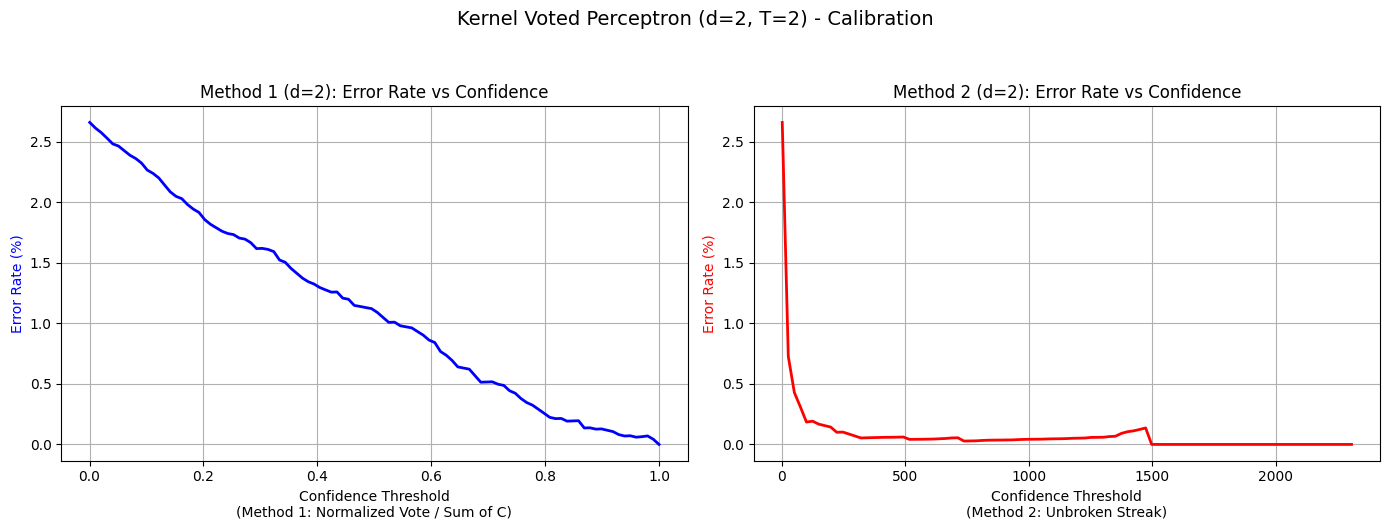

In [11]:
print("Generating Plots...")

mistakes_mask = (y_pred_all != y_test)
overall_error = np.mean(mistakes_mask) * 100
print(f"Overall Baseline Test Error: {overall_error:.2f}%")

def get_error_rates(confidences, mistakes):
    thresholds = np.linspace(np.min(confidences), np.max(confidences), 100)
    error_rates = []
    
    for t in thresholds:
        keep_mask = confidences >= t
        retained = np.sum(keep_mask)
        
        if retained > 0:
            # We enforce a minimum sample size to avoid massive artificial spikes like the red graph
            if retained > 20: 
                error_rate = np.mean(mistakes[keep_mask]) * 100
                error_rates.append(error_rate)
            else:
                error_rates.append(np.nan)
        else:
            error_rates.append(np.nan)
            
    return thresholds, error_rates

t1, err1 = get_error_rates(conf_method_1, mistakes_mask)
t2, err2 = get_error_rates(conf_method_2, mistakes_mask)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(t1, err1, 'b-', label='Error Rate (%)', linewidth=2)
ax1.set_xlabel('Confidence Threshold\n(Method 1: Normalized Vote / Sum of C)')
ax1.set_ylabel('Error Rate (%)', color='b')
ax1.set_title(f'Method 1 (d={d}): Error Rate vs Confidence')
ax1.grid(True)

ax2.plot(t2, err2, 'r-', label='Error Rate (%)', linewidth=2)
ax2.set_xlabel('Confidence Threshold\n(Method 2: Unbroken Streak)')
ax2.set_ylabel('Error Rate (%)', color='r')
ax2.set_title(f'Method 2 (d={d}): Error Rate vs Confidence')
ax2.grid(True)

plt.suptitle(f"Kernel Voted Perceptron (d={d}, T={T_exp}) - Calibration", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()